# Korelace indexů a podílu preferenčních hlasů pro ženy

In [41]:
# AGREGACE VÝSLEDKŮ NA OBEC

import pandas as pd
vysledky_volby = pd.read_csv("2025_preferencni_hlasy_zeny_oksrky.csv")
vysledky_volby["KodObec"] = vysledky_volby["KodObec"].astype(str)

volby_obce = vysledky_volby.groupby("KodObec").apply(
    lambda x: pd.Series({
        "PROCPOC_obce": (x["PROCPOC"] * x["HLASYCELKEM"]).sum() / x["HLASYCELKEM"].sum() if x["HLASYCELKEM"].sum() > 0 else pd.NA,
        "HLASYCELKEM_obce": x["HLASYCELKEM"].sum()
    })
).reset_index()

volby_obce["PROCPOC_obce"] = pd.to_numeric(volby_obce["PROCPOC_obce"], errors='coerce')
volby_obce["PROCPOC_obce"] = volby_obce["PROCPOC_obce"] * 100  #převod na procenta
volby_obce["HLASYCELKEM_obce"] = volby_obce["HLASYCELKEM_obce"].astype("Int64")


In [42]:
# import csv s indexy

vybavenost = pd.read_csv("index_obcanska_vybavenost.csv")
vybavenost["KodObec"] = vybavenost["KodObec"].astype(str) 

soceko = pd.read_csv("index_socioekonomicky.csv")
soceko["KodObec"] = soceko["KodObec"].astype(str) 

vzdelani = pd.read_csv("index_vzdelani.csv")
vzdelani["KodObec"] = vzdelani["KodObec"].astype(str) 

vek = pd.read_csv("index_vekove_struktury.csv")
vek["KodObec"] = vek["KodObec"].astype(str) 

In [49]:
korelace = volby_obce.merge(vybavenost, on="KodObec", how="left")
korelace = korelace.merge(soceko, on="KodObec", how="left")
korelace = korelace.merge(vzdelani, on="KodObec", how="left")
korelace = korelace.merge(vek, on="KodObec", how="left")

korelace = korelace.rename(columns={"PROCPOC_obce": "PodilPrefHlasyZeny_obec"})

korelace.info()
korelace.columns.to_list

<class 'pandas.DataFrame'>
RangeIndex: 6254 entries, 0 to 6253
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   KodObec                  6254 non-null   str    
 1   PodilPrefHlasyZeny_obec  6252 non-null   float64
 2   HLASYCELKEM_obce         6254 non-null   Int64  
 3   index_vybavenosti        6254 non-null   int64  
 4   index_socioekonomicky    6254 non-null   float64
 5   index_vzdelani           6246 non-null   float64
 6   index_stari              6254 non-null   float64
 7   index_zavisloti          6254 non-null   float64
 8   index_zavisloti_2        6254 non-null   float64
 9   index_ekonom_zatizeni    6254 non-null   float64
dtypes: Int64(1), float64(7), int64(1), str(1)
memory usage: 494.8 KB


<bound method IndexOpsMixin.tolist of Index(['KodObec', 'PodilPrefHlasyZeny_obec', 'HLASYCELKEM_obce',
       'index_vybavenosti', 'index_socioekonomicky', 'index_vzdelani',
       'index_stari', 'index_zavisloti', 'index_zavisloti_2',
       'index_ekonom_zatizeni'],
      dtype='str')>

,PodilPrefHlasyZeny_obec,index_vybavenosti
PodilPrefHlasyZeny_obec,1.000000,0.013911
index_vybavenosti,0.013911,1.000000


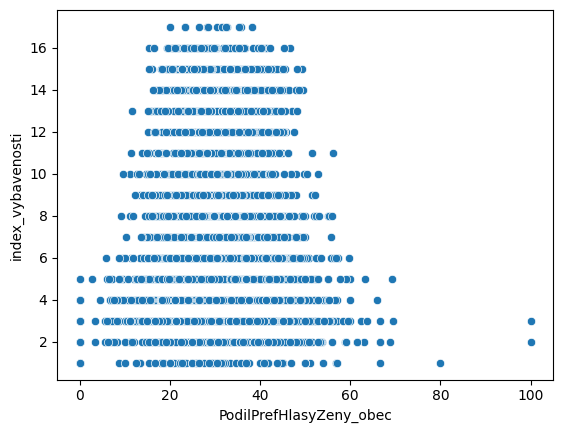

In [ ]:
# korelace a scatter plot - podíl prefenčních hlasuůpro ženy na obec a index občanské vybavenosti

import seaborn as sns 
sns.scatterplot(korelace, x="PodilPrefHlasyZeny_obec", y="index_vybavenosti")

korelace = korelace[["PodilPrefHlasyZeny_obec","index_vybavenosti"]]
korelace.corr()

,PodilPrefHlasyZeny_obec,index_vzdelani
PodilPrefHlasyZeny_obec,1.000000,-0.012896
index_vzdelani,-0.012896,1.000000


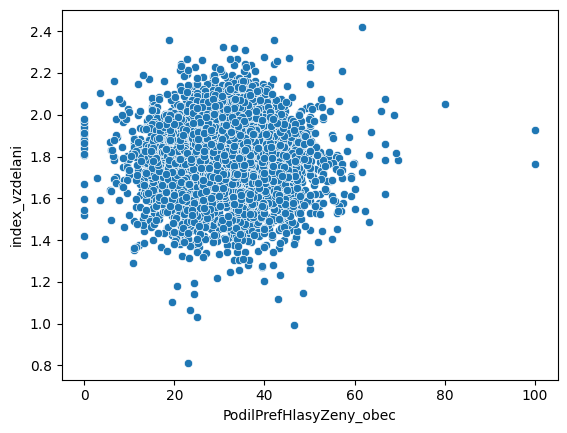

In [50]:
# korelace a scatter plot - podíl prefenčních hlasuůpro ženy na obec a index vzdělanosti

sns.scatterplot(korelace, x="PodilPrefHlasyZeny_obec", y="index_vzdelani")

korelace = korelace[["PodilPrefHlasyZeny_obec","index_vzdelani"]]
korelace.corr()